In [1]:
!pip install xgboost scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

In [4]:
from google.colab import files
uploaded = files.upload()

Saving train_data.csv to train_data.csv
Saving test_data.csv to test_data.csv


In [5]:
# ==========================================
# LOAD TRAIN & TEST DATA FROM FILES PANEL
# ==========================================

import pandas as pd
import os

# Step 1: Check current directory
print("Current working directory:")
print(os.getcwd())

print("\nFiles available here:")
print(os.listdir())

# Step 2: Load datasets (from same directory)
train_df = pd.read_csv('./train_data.csv')
test_df = pd.read_csv('./test_data.csv')

# Step 3: Verify
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain preview:")
print(train_df.head())

print("\nTest preview:")
print(test_df.head())

Current working directory:
/content

Files available here:
['.config', 'test_data.csv', 'train_data.csv', 'sample_data']

Train shape: (150150, 9)
Test shape: (13860, 8)

Train preview:
   record_ID      week  store_id  sku_id  total_price  base_price  \
0          1  17/01/11      8091  216418      99.0375    111.8625   
1          2  17/01/11      8091  216419      99.0375     99.0375   
2          3  17/01/11      8091  216425     133.9500    133.9500   
3          4  17/01/11      8091  216233     133.9500    133.9500   
4          5  17/01/11      8091  217390     141.0750    141.0750   

   is_featured_sku  is_display_sku  units_sold  
0                0               0          20  
1                0               0          28  
2                0               0          19  
3                0               0          44  
4                0               0          52  

Test preview:
   record_ID      week  store_id  sku_id  total_price  base_price  \
0     212645  16/07/1

After uploading `train_data.csv` and `test_data.csv` using the files tab, run the following cell to move them to your Google Drive's root folder, matching the paths used in the previous code.

In [6]:
import pandas as pd

print("Loading datasets...")

train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")

Loading datasets...
Train shape: (150150, 9) | Test shape: (13860, 8)


In [7]:
test_df

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku
0,212645,16/07/13,8091,216418,108.3000,108.3000,0,0
1,212646,16/07/13,8091,216419,109.0125,109.0125,0,0
2,212647,16/07/13,8091,216425,133.9500,133.9500,0,0
3,212648,16/07/13,8091,216233,133.9500,133.9500,0,0
4,212649,16/07/13,8091,217390,176.7000,176.7000,0,0
...,...,...,...,...,...,...,...,...
13855,232281,01/10/13,9984,223245,241.5375,241.5375,0,0
13856,232282,01/10/13,9984,223153,240.8250,240.8250,0,0
13857,232285,01/10/13,9984,245338,382.6125,401.8500,1,1
13858,232286,01/10/13,9984,547934,191.6625,191.6625,0,0


In [8]:
train_df

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52
...,...,...,...,...,...,...,...,...,...
150145,212638,09/07/13,9984,223245,235.8375,235.8375,0,0,38
150146,212639,09/07/13,9984,223153,235.8375,235.8375,0,0,30
150147,212642,09/07/13,9984,245338,357.6750,483.7875,1,1,31
150148,212643,09/07/13,9984,547934,141.7875,191.6625,0,1,12


In [9]:
# ==========================================
# 2. PREPROCESSING & FEATURE ENGINEERING
# ==========================================
print("Processing data...")

def preprocess_features(df):
    df = df.copy()

    # 1. Handle Missing Values
    # There is 1 missing value in 'total_price' in the train set.
    # The safest way to fill it is by using the 'base_price' for that row.
    df['total_price'] = df['total_price'].fillna(df['base_price'])

    # 2. Date/Time Features
    # Convert 'week' from text (dd/mm/yy) to a proper datetime format
    df['week'] = pd.to_datetime(df['week'], format='%d/%m/%y')

    # Extract year, month, day, and week of the year
    df['year'] = df['week'].dt.year
    df['month'] = df['week'].dt.month
    df['day'] = df['week'].dt.day
    df['week_of_year'] = df['week'].dt.isocalendar().week.astype(int)

    # 3. Discount Features
    # Calculate how much discount is being offered
    df['discount_amount'] = df['base_price'] - df['total_price']

    # Calculate discount percentage (handling division by zero just in case)
    df['discount_percent'] = (df['discount_amount'] / df['base_price']) * 100
    df['discount_percent'] = df['discount_percent'].fillna(0)

    # 4. Drop columns that shouldn't go into the model
    # We drop 'week' because we extracted the useful date parts
    df = df.drop(['week'], axis=1)

    return df

# Apply the preprocessing steps to both train and test datasets
train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

Processing data...


In [10]:
# Define our features (X) and target variable (y)
target_col = 'units_sold'
drop_cols = ['record_ID', target_col]

In [11]:
X = train_processed.drop(columns=[col for col in drop_cols if col in train_processed.columns])
y = train_processed[target_col]

In [12]:
# Save the test record IDs for the final submission file
test_ids = test_processed['record_ID']
X_test_final = test_processed.drop(columns=['record_ID'])

In [13]:
# ==========================================
# 4. MODEL TRAINING
# ==========================================
print("Training the XGBoost Model on all training data...")
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=10,
    random_state=62)

# Notice we are using the full 'X' and 'y' here, not X_train/y_train
model.fit(X, y)

Training the XGBoost Model on all training data...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import r2_score

# ==========================================
# 5. CHECK TRAINING ACCURACY (FIT) - UPDATED
# ==========================================
print("\nChecking how well the model fit the training data...")
y_train_pred = model.predict(X)

# Ensure no negative sales are predicted
y_train_pred = np.maximum(y_train_pred, 0)

# Calculate Accuracy Metrics using your variables: y and y_train_pred
r2_train = r2_score(y, y_train_pred)
rmse = np.sqrt(mean_squared_error(y, y_train_pred))
mae = mean_absolute_error(y, y_train_pred)

print(f"--- Training Fit Accuracy ---")
print(f"✅ Training R2 Score (Accuracy): {r2_train * 100:.2f}%")
print(f"Training RMSE: {rmse:.2f}")
print(f"Training MAE: {mae:.2f}")



Checking how well the model fit the training data...
--- Training Fit Accuracy ---
✅ Training R2 Score (Accuracy): 96.74%
Training RMSE: 10.88
Training MAE: 7.59


In [16]:
# ==========================================
# 6. FINAL PREDICTIONS FOR SUBMISSION
# ==========================================
print("\nGenerating final predictions for the test file...")
final_predictions = model.predict(X_test_final)
final_predictions = np.maximum(final_predictions, 0) # Ensure no negative sales

# Create a final submission DataFrame
submission = pd.DataFrame({
    'record_ID': test_ids,
    'units_sold': final_predictions
})


Generating final predictions for the test file...


In [17]:

# Save to CSV so you can download it from Colab
submission.to_csv('/content/submission.csv', index=False)
print("Saved final predictions to '/content/submission.csv'!")
print("You can now download this file from the Colab files tab.")


Saved final predictions to '/content/submission.csv'!
You can now download this file from the Colab files tab.



Generating visual reports...


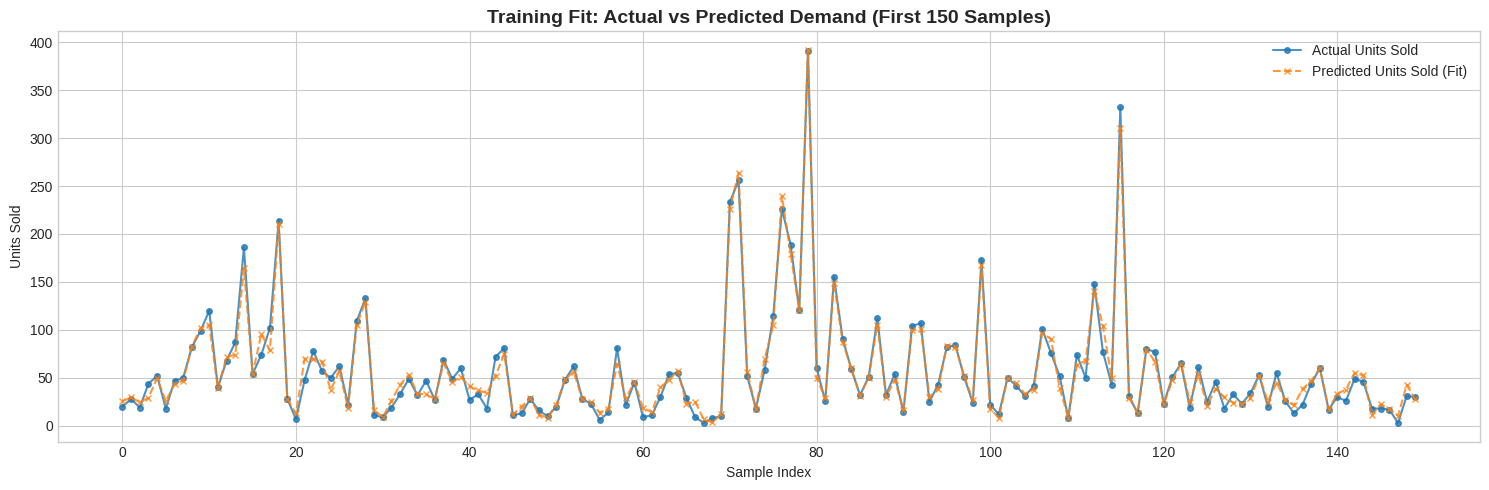

In [18]:



# ==========================================
# 7. DATA VISUALIZATIONS
# ==========================================
print("\nGenerating visual reports...")
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Training Fit (Actual vs Predicted Line Plot) ---
plt.figure(figsize=(15, 5))
plt.plot(y.values[:150], label='Actual Units Sold', color='#1f77b4', marker='o', markersize=4, alpha=0.8)
plt.plot(y_train_pred[:150], label='Predicted Units Sold (Fit)', color='#ff7f0e', linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.title('Training Fit: Actual vs Predicted Demand (First 150 Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


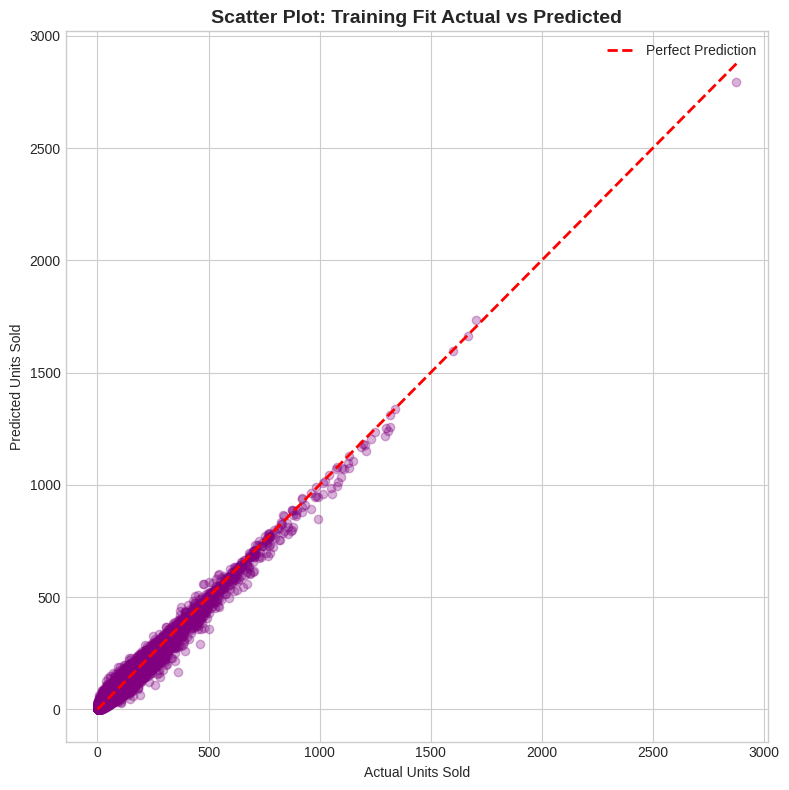

In [19]:
# --- Plot 2: Scatter Plot of the Fit ---
plt.figure(figsize=(8, 8))
plt.scatter(y, y_train_pred, alpha=0.3, color='purple')
max_val = max(max(y), max(y_train_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Scatter Plot: Training Fit Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

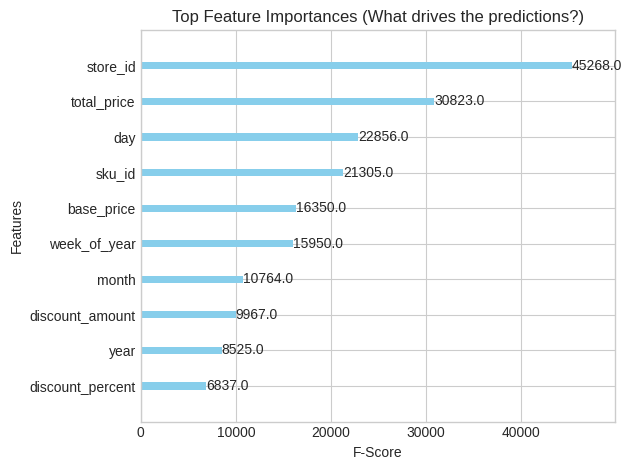

In [20]:



# --- Plot 3: Feature Importance ---
# This remains perfectly valid! It shows you what the AI thinks is most important.
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='weight',
                    title='Top Feature Importances (What drives the predictions?)',
                    xlabel='F-Score', color='skyblue')
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np

print("==========================================")
print(" 🛒 DEMAND FORECASTING - MANUAL PREDICTION")
print("==========================================")

# 1. Take raw inputs from the user
date_input = input("Enter Date (DD/MM/YY) (e.g., 15/08/13): ")
store_id = int(input("Store ID (e.g., 8091): "))
sku_id = int(input("SKU ID (e.g., 216418): "))
base_price = float(input("Base Price (e.g., 150.0): "))
total_price = float(input("Total Checkout Price (e.g., 130.0): "))
is_featured = int(input("Featured? (1 for Yes, 0 for No): "))
is_display = int(input("On Display? (1 for Yes, 0 for No): "))

print("\nProcessing your data... ⚙️")

# 2. Process features automatically in the background
date_obj = pd.to_datetime(date_input, format='%d/%m/%y')
discount_amount = base_price - total_price
discount_percent = (discount_amount / base_price) * 100 if base_price > 0 else 0

# 3. Format the data into a DataFrame exactly like the training data
user_data = pd.DataFrame({
    'store_id': [store_id],
    'sku_id': [sku_id],
    'total_price': [total_price],
    'base_price': [base_price],
    'is_featured_sku': [is_featured],
    'is_display_sku': [is_display],
    'year': [date_obj.year],
    'month': [date_obj.month],
    'day': [date_obj.day],
    'week_of_year': [date_obj.isocalendar().week],
    'discount_amount': [discount_amount],
    'discount_percent': [discount_percent]
})

# Reorder columns to match 'X' (the data the model was trained on)
user_data = user_data[X.columns]

# 4. Make the prediction!
prediction = max(0, int(np.round(model.predict(user_data)[0])))

print("\n=======================================================")
print(f" 🚀 AI PREDICTION: You are expected to sell {prediction} units!")
print("=======================================================")

 🛒 DEMAND FORECASTING - MANUAL PREDICTION
Enter Date (DD/MM/YY) (e.g., 15/08/13): 12/09/26
Store ID (e.g., 8091): 9826
SKU ID (e.g., 216418): 25657369
Base Price (e.g., 150.0): 147
Total Checkout Price (e.g., 130.0): 159
Featured? (1 for Yes, 0 for No): 1
On Display? (1 for Yes, 0 for No): 1

Processing your data... ⚙️

 🚀 AI PREDICTION: You are expected to sell 64 units!


In [23]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
print("✅ Model exported successfully!")

✅ Model exported successfully!


In [24]:
import os
print(os.listdir())

['.config', 'model.pkl', 'test_data.csv', 'train_data.csv', 'submission.csv', 'sample_data']


In [25]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
!git --version

git version 2.34.1


In [27]:
!git clone https://github.com/tushardaga69-official/AI-Project-.git

Cloning into 'AI-Project-'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 261.82 KiB | 10.07 MiB/s, done.


In [38]:
from google.colab import files
files.download('AI_Project.ipynb')

FileNotFoundError: Cannot find file: AI_Project.ipynb